In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/ximenamarin/Desktop/extraccion_caracteristicas/Extraccion_de_Caracteristicas/Actividad 4.1/Analisis GAC Full7agosto 2026(Leads Reales).csv')

In [3]:
df.head(5)

,Efectivadad de Leads,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,NaN,"30,189","3,851","5,748",510,929,"17,748","6,545",720,4.0%,64.0%,NaN,NaN
1,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,NaN,NaN
2,2024,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
4,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN


In [8]:
Leads_Reales = df.iloc[3:31, 0:12].copy()
Leads_Reales.columns = ["Año", "Mes", "Total", "Ilocalizable", "No Contesta",
                         "D. Incorrectos", "Duplicados", "Efectivos", "Abiertos",
                         "Ventas", "Conversion", "Efectividad de Leads"]
 
variables = ["Total", "Ilocalizable", "No Contesta", "D. Incorrectos",
             "Duplicados", "Efectivos", "Abiertos", "Ventas",
             "Conversion", "Efectividad de Leads"]

In [ ]:
#limpieza de datos
for col in variables:
    Leads_Reales[col] = (
        Leads_Reales[col].astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    Leads_Reales[col] = pd.to_numeric(Leads_Reales[col], errors="coerce")
 
#Quitamos el mes vacío (2024-Enero no tiene datos)
Leads_Reales = Leads_Reales.dropna(subset=variables, how="all").reset_index(drop=True)

In [10]:
Leads_Reales.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   2 non-null      str    
 1   Mes                   28 non-null     str    
 2   Total                 28 non-null     int64  
 3   Ilocalizable          28 non-null     int64  
 4   No Contesta           28 non-null     int64  
 5   D. Incorrectos        28 non-null     int64  
 6   Duplicados            28 non-null     int64  
 7   Efectivos             28 non-null     int64  
 8   Abiertos              28 non-null     int64  
 9   Ventas                28 non-null     int64  
 10  Conversion            28 non-null     float64
 11  Efectividad de Leads  28 non-null     int64  
dtypes: float64(1), int64(9), str(2)
memory usage: 2.8 KB


In [ ]:
for columna in variables:
 
    print(f"VARIABLE: {columna}")
 
    #Total de la población "n"
    n = Leads_Reales[columna].count()
    print("n =", n)

VARIABLE: Total
n = 28
VARIABLE: Ilocalizable
n = 28
VARIABLE: No Contesta
n = 28
VARIABLE: D. Incorrectos
n = 28
VARIABLE: Duplicados
n = 28
VARIABLE: Efectivos
n = 28
VARIABLE: Abiertos
n = 28
VARIABLE: Ventas
n = 28
VARIABLE: Conversion
n = 28
VARIABLE: Efectividad de Leads
n = 28


In [14]:
#Obtenemos el limite superior y el límite inferior de la columna objetivo
Max = Leads_Reales[columna].max()
Min = Leads_Reales[columna].min()
Limites = [Min, Max]
print("Limites =", Limites)

Limites = [np.int64(39), np.int64(83)]


In [15]:
#Calculamos el rango R
R = Max - Min
print("R =", R)

R = 44


In [17]:
 #Calculamos el número de Intervalos de Clase "ni", aplicando la regla de Sturges
ni = 1 + 3.32 * np.log10(n)
print("ni =", ni)
ni = round(ni)  # redondeamos al entero de clases a usar

ni = 5.8045646640561674


In [18]:
i = R / ni
print("i =", i)

i = 7.333333333333333


In [19]:
margen = i * 0.01 if i > 0 else 0.01
intervalos = np.linspace(Min - margen, Max + margen, ni + 1)
print("intervalos =", intervalos)

intervalos = [38.92666667 46.28444444 53.64222222 61.         68.35777778 75.71555556
 83.07333333]


In [20]:
categorias = [
    f"Categoría{k+1}({intervalos[k]:.1f}-{intervalos[k+1]:.1f})"
    for k in range(ni)
    ]

In [21]:
columna_categorizada = pd.cut(
    x=Leads_Reales[columna], bins=intervalos, labels=categorias
    )

In [22]:
Tabla_freq = columna_categorizada.value_counts().reset_index()
Tabla_freq.columns = [columna, "count"]
print(Tabla_freq)

    Efectividad de Leads  count
0  Categoría5(68.4-75.7)      7
1  Categoría2(46.3-53.6)      5
2  Categoría3(53.6-61.0)      5
3  Categoría4(61.0-68.4)      5
4  Categoría1(38.9-46.3)      3
5  Categoría6(75.7-83.1)      3


In [23]:
Filtro = Tabla_freq[Tabla_freq["count"] > 0]

In [24]:
Filtro_index = Filtro.set_index(columna)

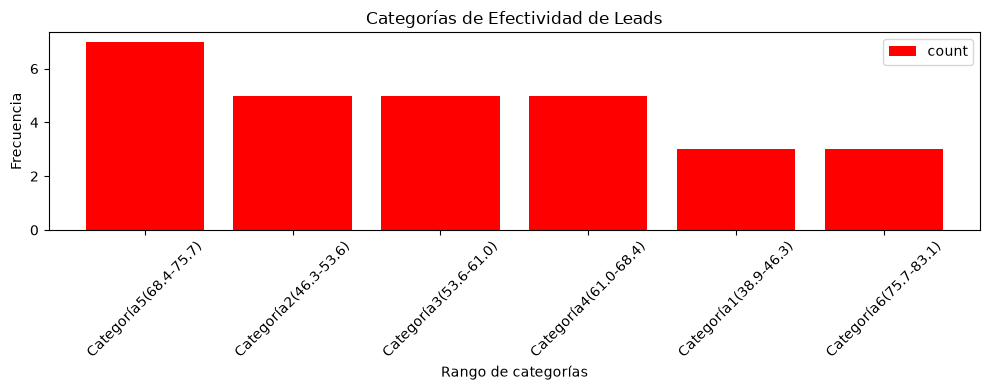

In [25]:
Filtro_index.plot(kind="bar", width=0.8, figsize=(10, 4), color="red", rot=45)
plt.title(f"Categorías de {columna}")
plt.xlabel("Rango de categorías")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()